# Módulo: Inteligencia de Negocios

## Tarea 1: Configuración de base de datos sources y entorno para ETL en Python

## Dominio: Salud

## Realizado por:
- Cristian Gonzalez
- Oscar Amagua
- Rafael Espinosa

## Grupo
Nro. 4

La idea principal de esta práctica es que sean obtenidas las fuentes de datos y configurar el entorno de desarrollo, los cuales serán el eje fundamental para el proyecto ETL.

![Diseño DB Covid.jpeg](Dise%C3%B1o%20BD/Dise%C3%B1o%20DB%20Covid.jpeg)

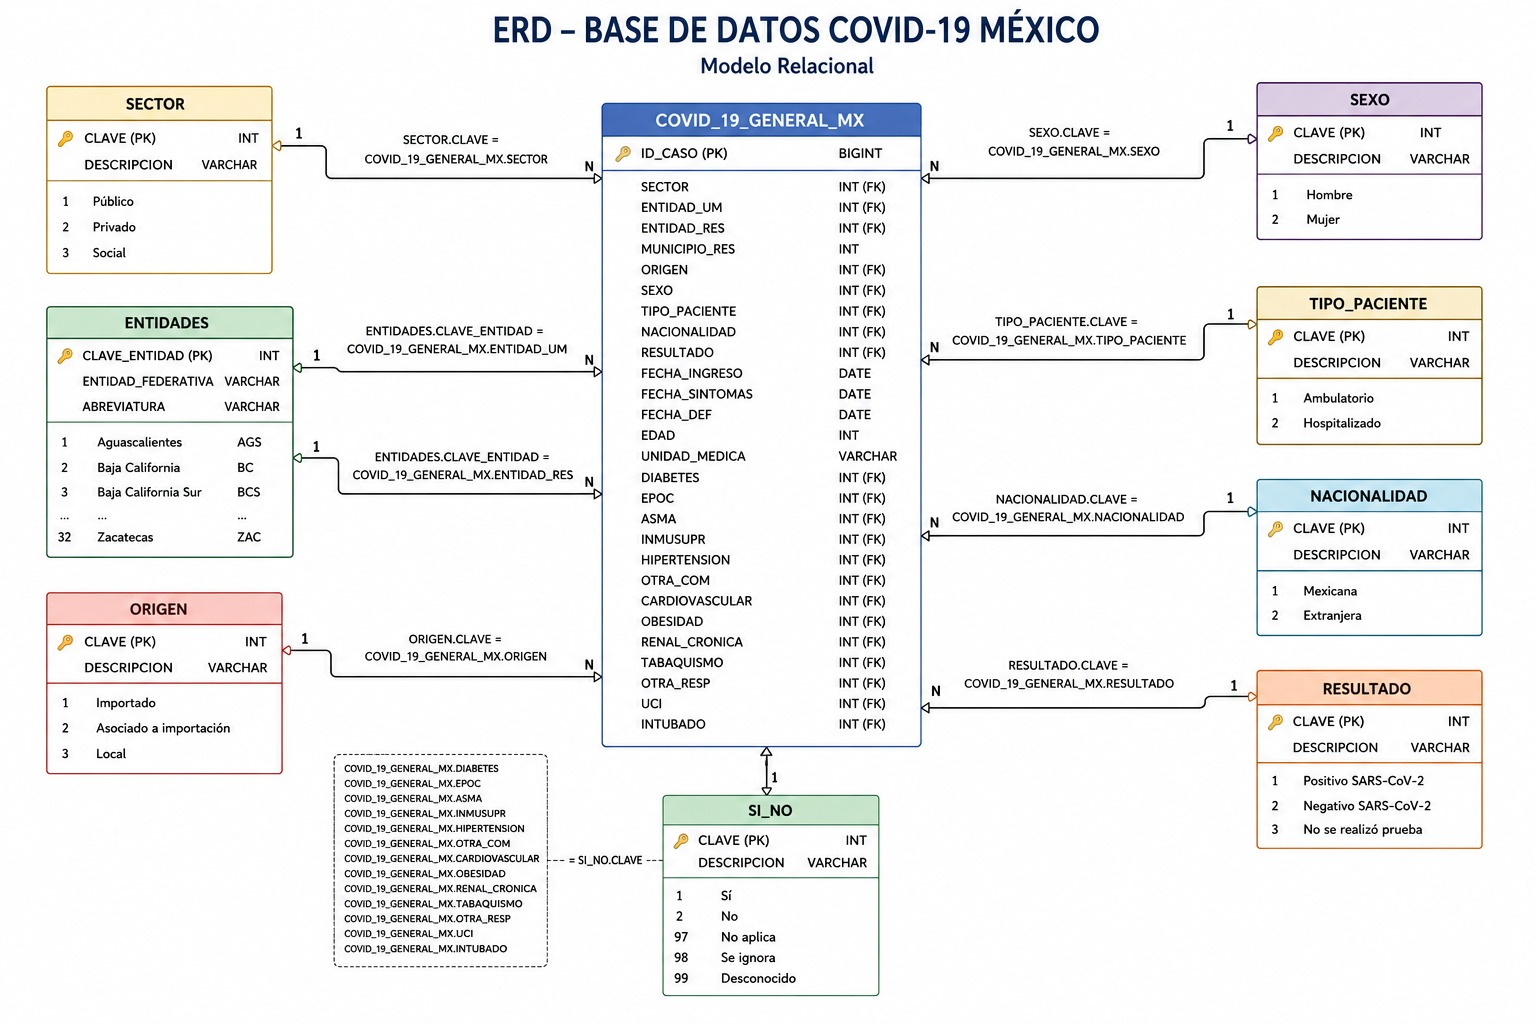

## Introducción:
Este proyecto está enfocado en el análisis de los datos relacionados con la enfermedad de COVID-19 en México. Su propósito principal es comprender el proceso de diseño y construcción de un modelo dimensional en esquema estrella (Star Schema), utilizado ampliamente en soluciones de inteligencia de negocios (Business Intelligence) y analítica de datos.

A partir de un conjunto de datos públicos, se desarrollará un proceso de integración, transformación y almacenamiento de la información en una base de datos orientada al análisis. Posteriormente, se diseñará un modelo analítico que facilite la consulta eficiente de grandes volúmenes de datos y permita obtener información relevante para la toma de decisiones.

Como parte del proyecto, se identificarán las tablas de dimensiones y la tabla de hechos, estableciendo las relaciones necesarias para representar la información de manera estructurada y optimizada. Además, se implementarán procesos de carga de datos (ETL), con el fin de garantizar la consistencia y calidad de la información.

Finalmente, el modelo desarrollado servirá como base para la generación de consultas, indicadores, reportes y visualizaciones que permitan analizar el comportamiento de la pandemia en México desde diferentes perspectivas, como la distribución geográfica de los casos, las características demográficas de los pacientes, los resultados de laboratorio, las instituciones de salud involucradas y otros factores de interés. De esta manera, el proyecto busca proporcionar una visión práctica sobre el diseño de almacenes de datos (Data Warehouse) y la aplicación de modelos analíticos para la explotación eficiente de la información.

## Importación de Dependencias


In [184]:
import os

import pandas as pd
from dotenv import load_dotenv
load_dotenv()
from sqlalchemy import create_engine

## Fase de Extracción de datos

En esta fase vamos a extraer los datos de nuestros sources

- Base de Datos ----> Entidades, Nacionalidad, Origen, Resultado --> Información de tablas
- Información en formato json ----> Sector --> Fuente de datos de sectores
- Información eb Formato CSV ----> covid-19_general_MX --> Información correspondiente a las fechas de ingreso de los pacientes, asociada a las diferentes afectaciones y manifestaciones sintomáticas registradas durante la atención médica.

### Manejo de Variables de Entorno

In [185]:
DB_USER= os.getenv("POSTGRES_USER")
DB_PASSWORD= os.getenv("POSTGRES_PASSWORD")
DB_NAME= os.getenv("POSTGRES_DB")
DB_HOST= os.getenv("POSTGRES_HOST")

## Cargando nuestra Base de Datos Posgres

Esta opción nos permite cargar los script de sql:

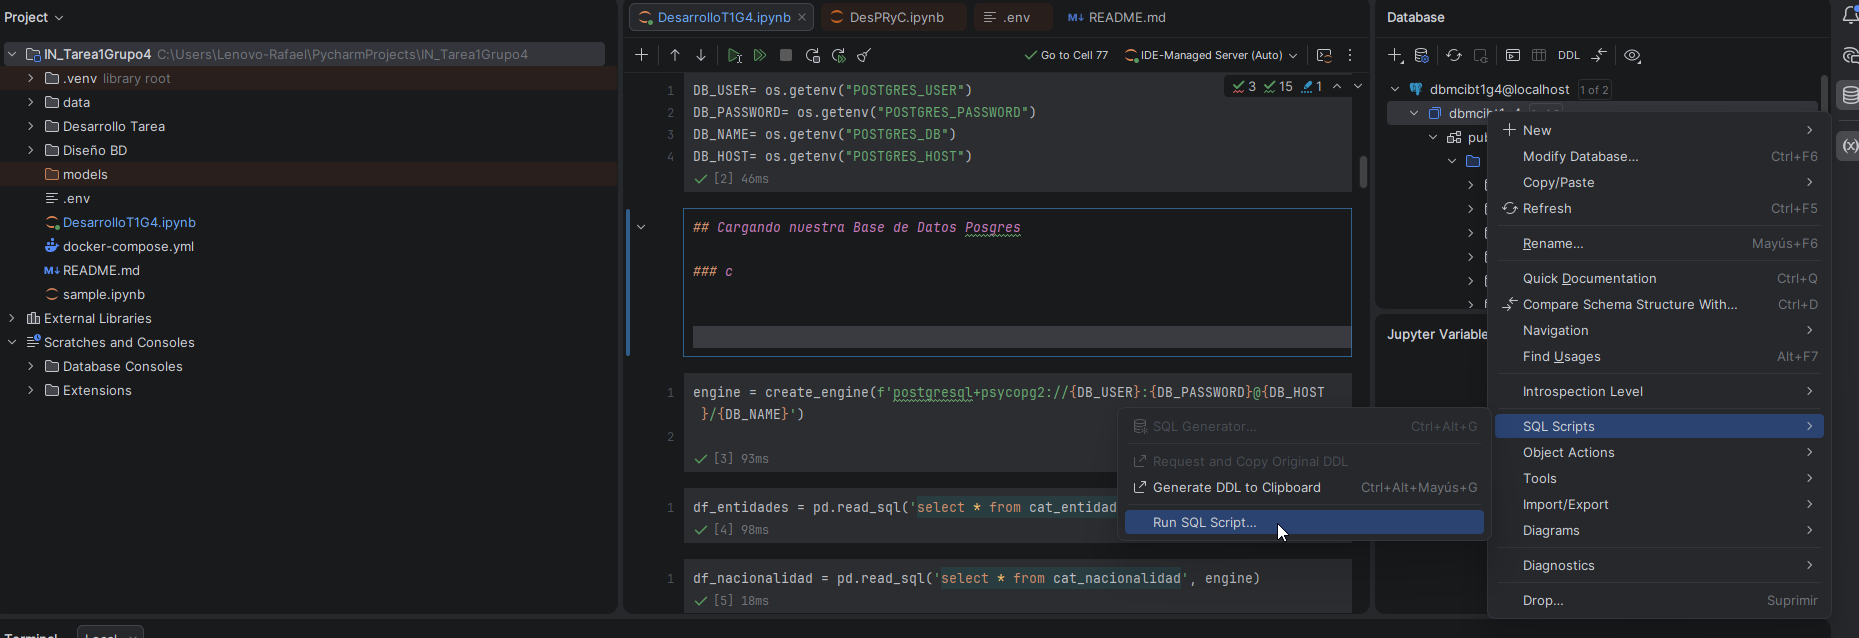

### Carga tabla cat_entidad_federativa

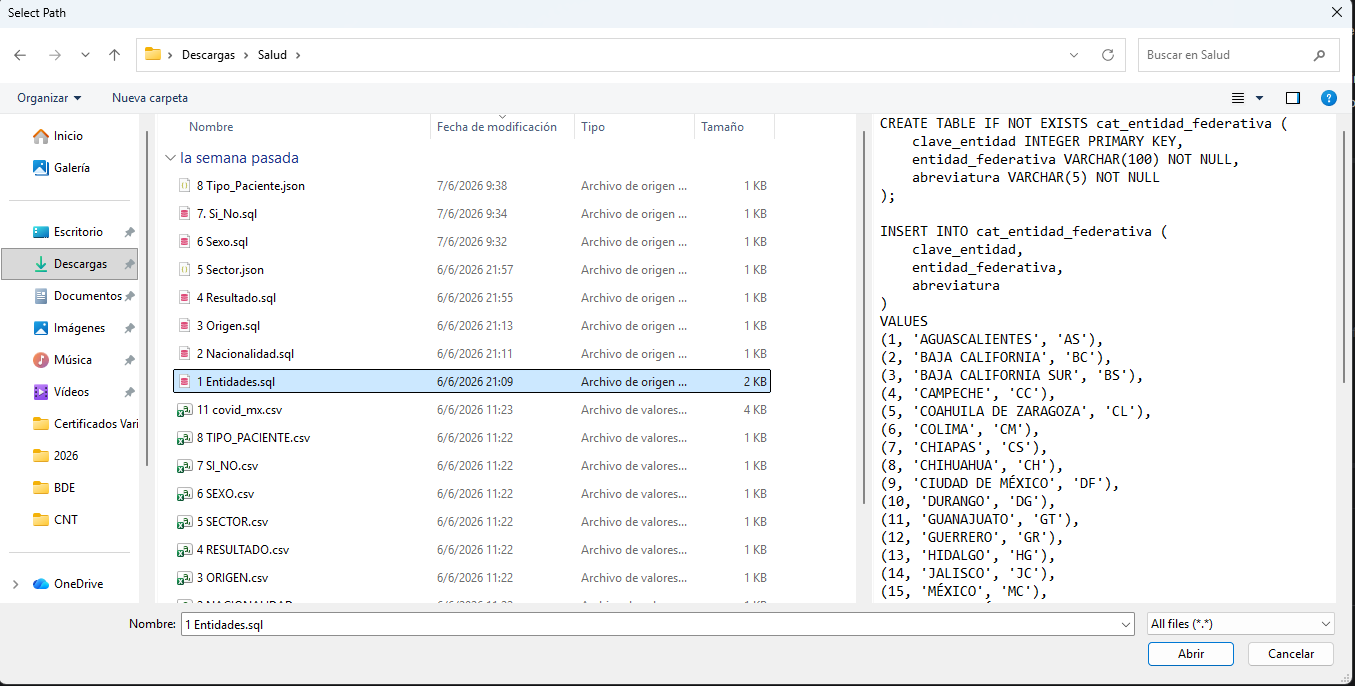

### Carga tabla cat_nacionalidad

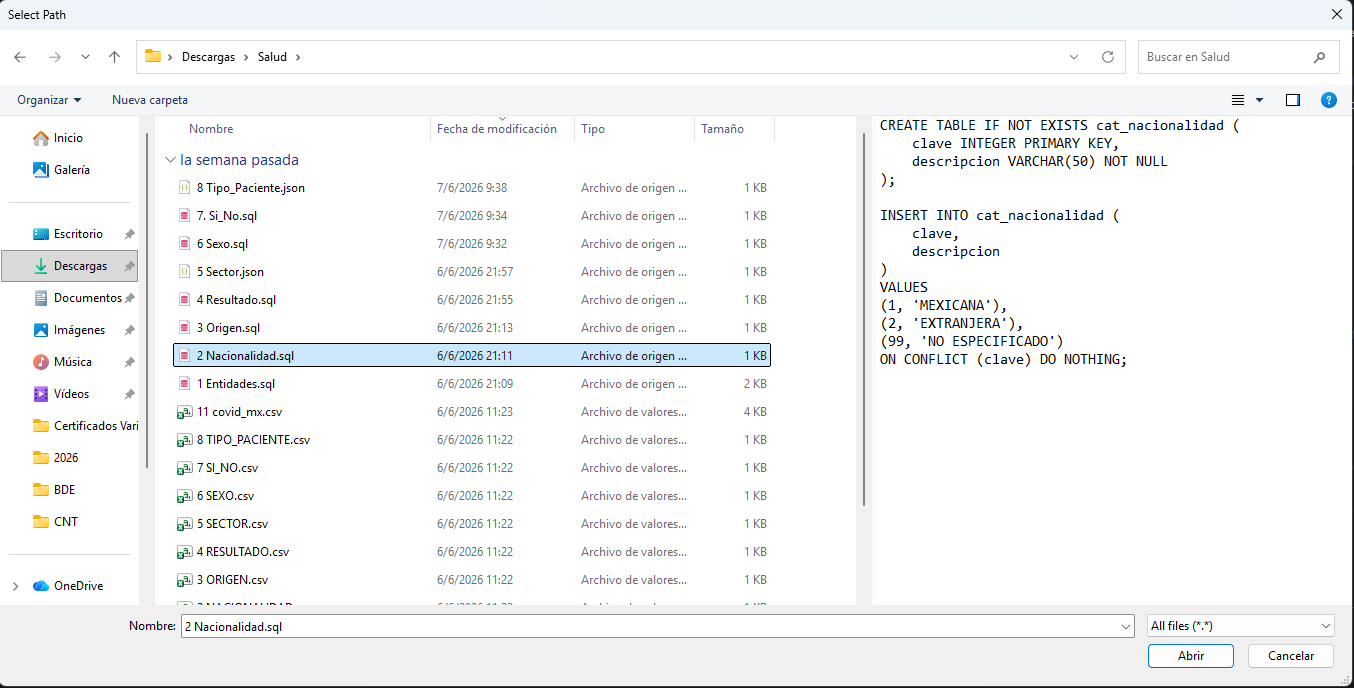

### Carga tabla cat_tipo_usmer (Origen)

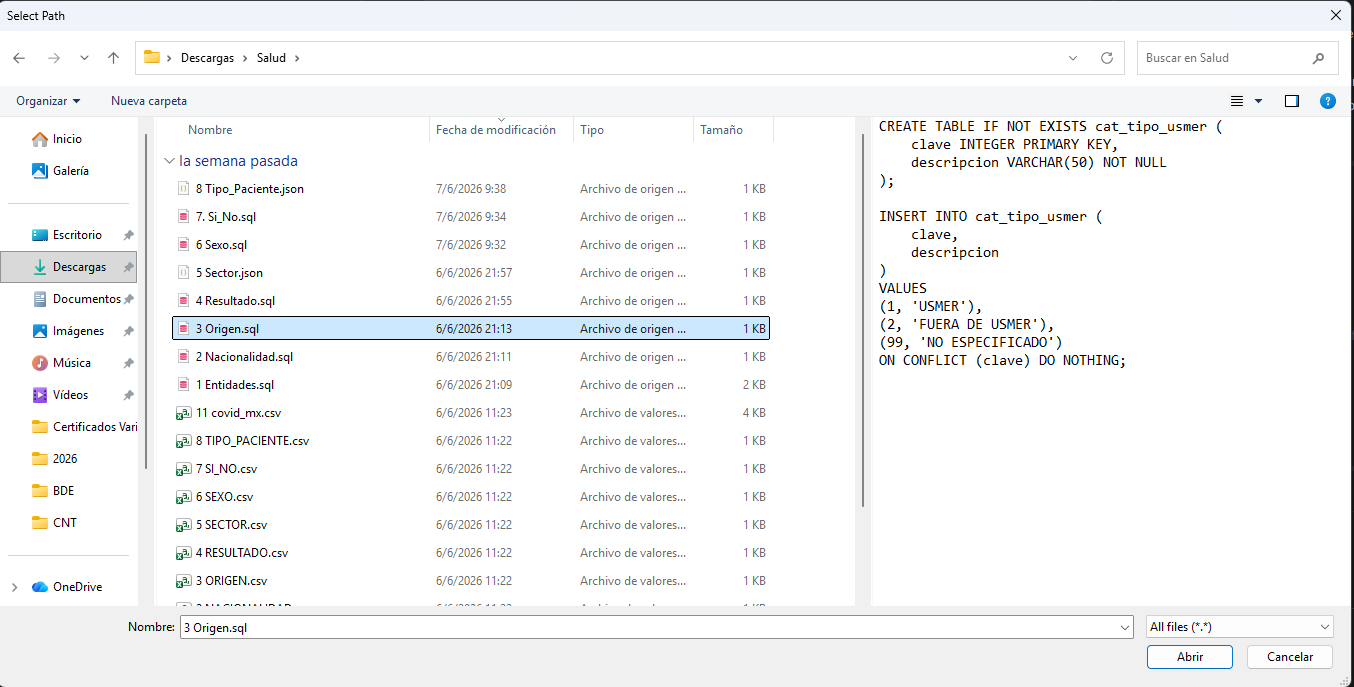

### Carga tabla cat_resultado_laboratorio

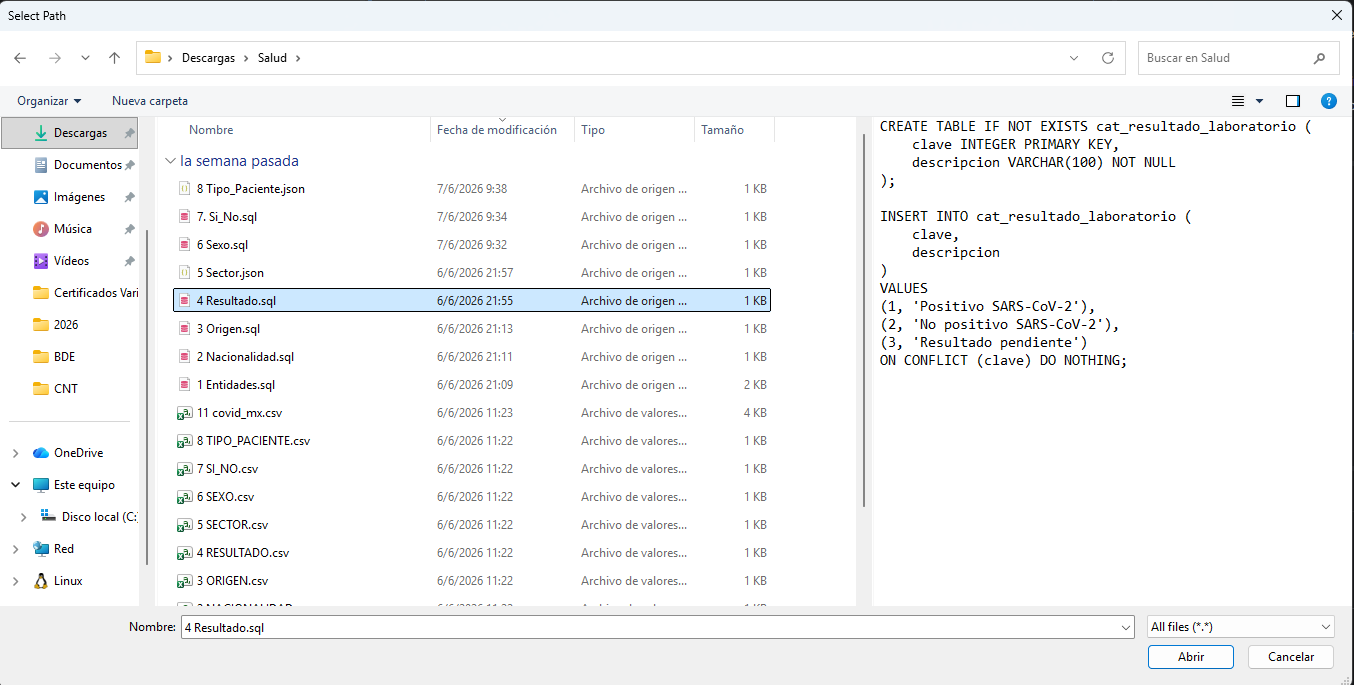

### Carga tabla cat_sexo

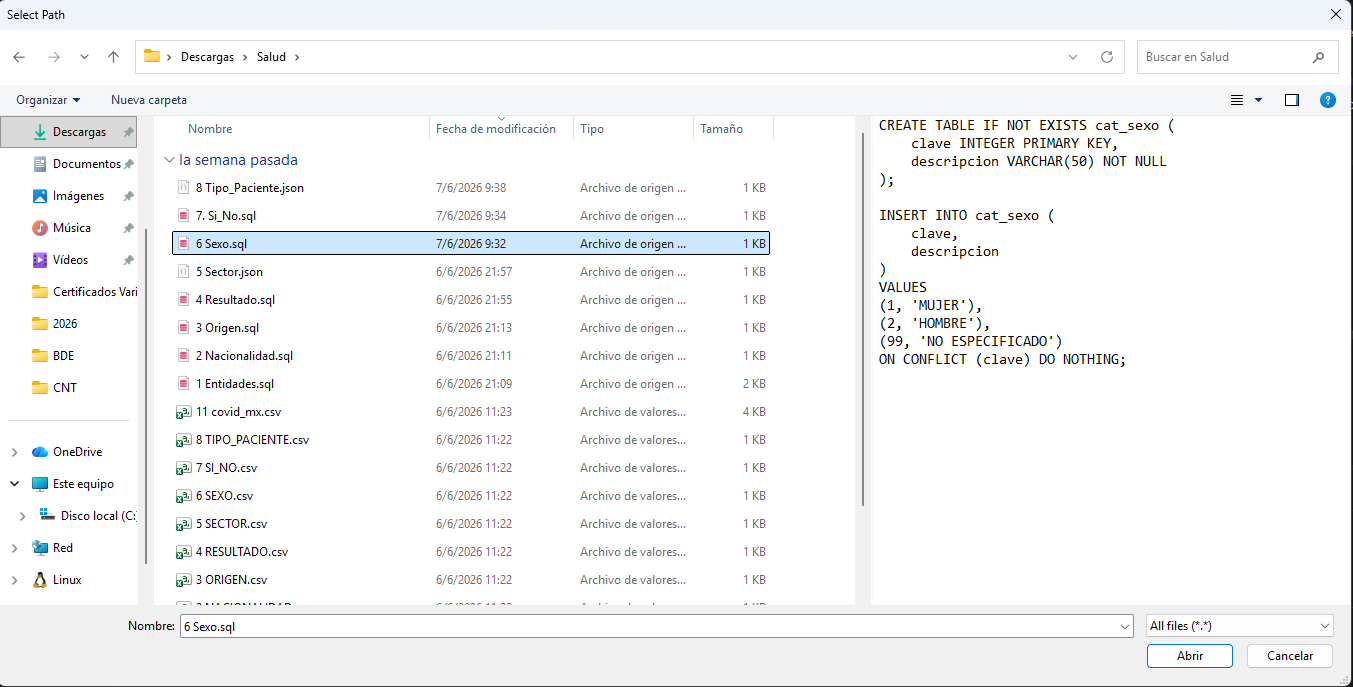

### Carga tabla cat_respuesta_binaria (Si_No)

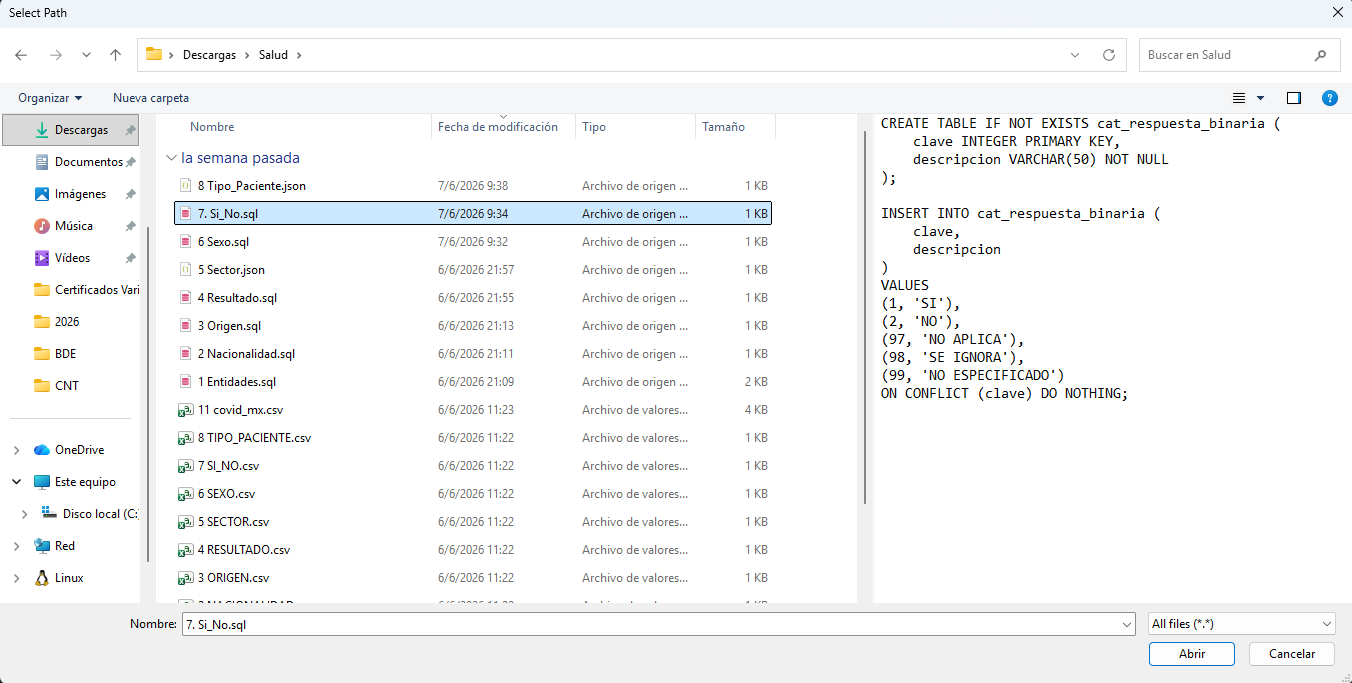


### BBDD Posgres

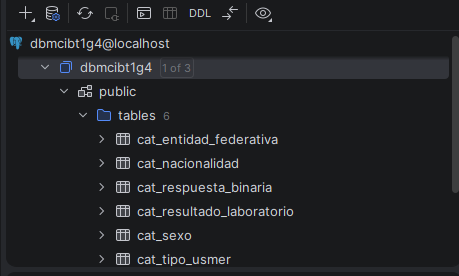


In [186]:
engine = create_engine(f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}')


In [187]:
df_entidades = pd.read_sql('select * from cat_entidad_federativa', engine)

In [188]:
df_nacionalidad = pd.read_sql('select * from cat_nacionalidad', engine)

In [189]:
df_origen = pd.read_sql('select * from cat_tipo_usmer', engine)

In [190]:
df_resultado = pd.read_sql('select * from cat_resultado_laboratorio', engine)

In [191]:
df_sexo = pd.read_sql('select * from cat_sexo', engine)

In [192]:
df_respuesta = pd.read_sql('select * from cat_respuesta_binaria', engine)

## Carga de Datos Tipo Json

In [193]:
df_sector = pd.read_json("data/5 Sector.json")

In [194]:
df_tipopaciente = pd.read_json('data/8 Tipo_Paciente.json')

In [195]:
df_entidades

,clave_entidad,entidad_federativa,abreviatura
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG


In [196]:
df_sector

,clave,descripcion
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR
5,6,ISSSTE
6,7,MUNICIPAL
7,8,PEMEX
8,9,PRIVADA
9,10,SEDENA


## Carga de Datos tipo CSV

In [197]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")

In [198]:
df_covidgeneral

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,2,2,1,2,2,2,2,99,1,97
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,2,2,2,2,2,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879603,879603,12,19,2,19,1,2020-07-02,2020-07-01,9999-99-99,97,...,2,2,2,2,2,2,2,1,3,97
879604,879604,3,26,2,26,2,2020-07-09,2020-07-02,9999-99-99,2,...,2,2,2,2,1,2,1,1,3,2
879605,879605,12,24,1,24,1,2020-07-16,2020-07-09,9999-99-99,97,...,2,2,2,1,2,2,2,2,3,97
879606,879606,12,9,1,9,1,2020-07-16,2020-07-11,9999-99-99,97,...,2,2,2,2,2,2,2,2,3,97


In [199]:
df_casosconfirmados = pd.read_csv('data/9 casos_confirmados.csv')

In [200]:
df_casosconfirmados

,Unnamed: 0,State,Sex,Age,Date,Confirmed
0,0,distrito federal,MASCULINO,28,2020-03-23,1
1,1,distrito federal,MASCULINO,49,2020-04-13,1
2,2,chihuahua,FEMENINO,67,2020-04-15,1
3,3,veracruz de ignacio de la llave,FEMENINO,41,2020-04-27,1
4,4,méxico,MASCULINO,43,2020-06-06,1
...,...,...,...,...,...,...
370707,724196,sinaloa,MASCULINO,77,2020-07-16,1
370708,724197,nuevo león,MASCULINO,79,2020-07-17,1
370709,724198,guanajuato,MASCULINO,35,2020-07-17,1
370710,724199,méxico,MASCULINO,36,2020-07-17,1


## Análisis de Cada DataFrame

El objetivo de este análisis es identificar y comprender las relaciones existentes entre las diferentes fuentes de datos que conforman el conjunto de información del proyecto. Esta etapa constituye el punto de partida para el diseño del modelo dimensional, permitiendo establecer las entidades, atributos y relaciones que darán origen al esquema estrella (Star Schema).

Durante este proceso se busca conocer en profundidad la estructura, el significado y la calidad de los datos, con el fin de determinar cuáles aportan valor al análisis y cómo deben organizarse para responder a las necesidades del negocio. La correcta comprensión de la información permitirá definir la tabla de hechos y las tablas de dimensiones, optimizando el modelo para facilitar la generación de indicadores, consultas analíticas y reportes.

En consecuencia, esta fase representa un paso fundamental en la construcción del modelo analítico, ya que garantiza que la información almacenada en el almacén de datos (Data Warehouse) sea consistente, confiable y adecuada para apoyar la toma de decisiones basada en datos.

In [201]:
df_entidades

,clave_entidad,entidad_federativa,abreviatura
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG


In [202]:
df_sector

,clave,descripcion
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR
5,6,ISSSTE
6,7,MUNICIPAL
7,8,PEMEX
8,9,PRIVADA
9,10,SEDENA


In [203]:
df_covidgeneral

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,2,2,1,2,2,2,2,99,1,97
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,2,2,2,2,2,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879603,879603,12,19,2,19,1,2020-07-02,2020-07-01,9999-99-99,97,...,2,2,2,2,2,2,2,1,3,97
879604,879604,3,26,2,26,2,2020-07-09,2020-07-02,9999-99-99,2,...,2,2,2,2,1,2,1,1,3,2
879605,879605,12,24,1,24,1,2020-07-16,2020-07-09,9999-99-99,97,...,2,2,2,1,2,2,2,2,3,97
879606,879606,12,9,1,9,1,2020-07-16,2020-07-11,9999-99-99,97,...,2,2,2,2,2,2,2,2,3,97


In [204]:
df_origen

,clave,descripcion
0,1,USMER
1,2,FUERA DE USMER
2,99,NO ESPECIFICADO


In [205]:
df_resultado

,clave,descripcion
0,1,Positivo SARS-CoV-2
1,2,No positivo SARS-CoV-2
2,3,Resultado pendiente


# Generar tres scripts de análisis de datos a cada uno de los Data Frames

Mostrar las 5 primeras filas de cada uno

## Base de Datos Postgres

In [206]:
df_entidades = pd.read_sql('select * from cat_entidad_federativa limit 5', engine)
df_entidades

,clave_entidad,entidad_federativa,abreviatura
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL


In [207]:
df_nacionalidad = pd.read_sql('select * from cat_nacionalidad limit 5', engine)
df_nacionalidad

,clave,descripcion
0,1,MEXICANA
1,2,EXTRANJERA
2,99,NO ESPECIFICADO


In [208]:
df_origen = pd.read_sql('select * from cat_tipo_usmer limit 5', engine)
df_origen

,clave,descripcion
0,1,USMER
1,2,FUERA DE USMER
2,99,NO ESPECIFICADO


In [209]:
df_resultado = pd.read_sql('select * from cat_resultado_laboratorio limit 5', engine)
df_resultado

,clave,descripcion
0,1,Positivo SARS-CoV-2
1,2,No positivo SARS-CoV-2
2,3,Resultado pendiente


In [210]:
df_sexo = pd.read_sql('select * from cat_sexo limit 5', engine)
df_sexo

,clave,descripcion
0,1,MUJER
1,2,HOMBRE
2,99,NO ESPECIFICADO


In [211]:
df_respuesta = pd.read_sql('select * from cat_respuesta_binaria limit 5', engine)
df_respuesta

,clave,descripcion
0,1,SI
1,2,NO
2,97,NO APLICA
3,98,SE IGNORA
4,99,NO ESPECIFICADO


## Datos Json


In [212]:
df_sector = pd.read_json("data/5 Sector.json")
df_sector.head(5)

,clave,descripcion
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR


In [213]:
df_tipopaciente = pd.read_json('data/8 Tipo_Paciente.json')
df_tipopaciente.head(5)

,clave,descripcion
0,1,AMBULATORIO
1,2,HOSPITALIZADO
2,99,NO ESPECIFICADO


## Archivo de Datos CVS


In [214]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
df_covidgeneral.head(5)

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,2,2,1,2,2,2,2,99,1,97
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,2,2,2,2,2,2,2,1,1,2


In [215]:
df_casosconfirmados = pd.read_csv('data/9 casos_confirmados.csv')
df_casosconfirmados.head(5)

,Unnamed: 0,State,Sex,Age,Date,Confirmed
0,0,distrito federal,MASCULINO,28,2020-03-23,1
1,1,distrito federal,MASCULINO,49,2020-04-13,1
2,2,chihuahua,FEMENINO,67,2020-04-15,1
3,3,veracruz de ignacio de la llave,FEMENINO,41,2020-04-27,1
4,4,méxico,MASCULINO,43,2020-06-06,1


## Identificar que columnas tienen nulos en los Data Frames


In [216]:
df_entidades = pd.read_sql('select * from cat_entidad_federativa', engine)
df_entidades.isnull().values.any()

np.False_

In [217]:
df_nacionalidad = pd.read_sql('select * from cat_nacionalidad', engine)
df_nacionalidad.isnull().values.any()


np.False_

In [218]:
df_origen = pd.read_sql('select * from cat_tipo_usmer', engine)
df_origen.isnull().values.any()

np.False_

In [219]:
df_resultado = pd.read_sql('select * from cat_resultado_laboratorio', engine)
df_resultado.isnull().values.any()

np.False_

In [220]:
df_sexo = pd.read_sql('select * from cat_sexo', engine)
df_sexo.isnull().values.any()

np.False_

In [221]:
df_respuesta = pd.read_sql('select * from cat_respuesta_binaria', engine)
df_respuesta.isnull().values.any()

np.False_

In [222]:
df_sector = pd.read_json("data/5 Sector.json")
df_sector.isnull().values.any()

np.False_

In [223]:
df_tipopaciente = pd.read_json('data/8 Tipo_Paciente.json')
df_tipopaciente.isnull().values.any()

np.False_

In [224]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
df_covidgeneral.isnull().values.any()

np.False_

In [225]:
df_casosconfirmados = pd.read_csv('data/9 casos_confirmados.csv')
df_casosconfirmados.isnull().values.any()

np.False_

## Contar cuantos valores faltan en cada columna


In [226]:
df_entidades = pd.read_sql('select * from cat_entidad_federativa', engine)
df_entidades.isnull().sum()

clave_entidad         0
entidad_federativa    0
abreviatura           0
dtype: int64

In [227]:
df_nacionalidad = pd.read_sql('select * from cat_nacionalidad', engine)
df_nacionalidad.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [228]:
df_origen = pd.read_sql('select * from cat_tipo_usmer', engine)
df_origen.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [229]:
df_resultado = pd.read_sql('select * from cat_resultado_laboratorio', engine)
df_resultado.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [230]:
df_sexo = pd.read_sql('select * from cat_sexo', engine)
df_sexo.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [231]:
df_respuesta = pd.read_sql('select * from cat_respuesta_binaria', engine)
df_respuesta.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [232]:
df_sector = pd.read_json("data/5 Sector.json")
df_sector.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [233]:
df_tipopaciente = pd.read_json('data/8 Tipo_Paciente.json')
df_tipopaciente.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [234]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
df_covidgeneral.isnull().sum()

Unnamed: 0        0
SECTOR            0
ENTIDAD_UM        0
SEXO              0
ENTIDAD_RES       0
TIPO_PACIENTE     0
FECHA_INGRESO     0
FECHA_SINTOMAS    0
FECHA_DEF         0
INTUBADO          0
NEUMONIA          0
EDAD              0
NACIONALIDAD      0
DIABETES          0
EPOC              0
ASMA              0
INMUSUPR          0
HIPERTENSION      0
OTRA_CON          0
CARDIOVASCULAR    0
OBESIDAD          0
RENAL_CRONICA     0
TABAQUISMO        0
OTRO_CASO         0
RESULTADO         0
UCI               0
dtype: int64

In [235]:
df_casosconfirmados = pd.read_csv('data/9 casos_confirmados.csv')
df_casosconfirmados.isnull().sum()

Unnamed: 0    0
State         0
Sex           0
Age           0
Date          0
Confirmed     0
dtype: int64

## Calcular el promedio, máximo y mínimo de una variable numérica a su elección
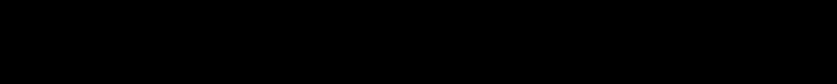

### Data frame df_covidgeneral

En el dataframe de df_covidgeneral nos permite obtener información de edad promedio de los casos analizados para COVID en México, considerando que:
1. Edad promedio: 42.55 años
2. Edad Máxima: 120 años
3. Edad Mínima: 0 años
Reflejando que todo paciente sufrio de esta enfermedad, para lo cual se realizaron los diferentes exámenes para confirmar COVID.

In [236]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
print(f"{df_covidgeneral["EDAD"].mean():.2f}")

42.55


In [237]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
print(df_covidgeneral["EDAD"].max())

120


In [238]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
print(df_covidgeneral["EDAD"].min())

0


## Encontrar el valor máximo y mínimo de dos variables agrupadas

### Data Frame df_casosconfirmados
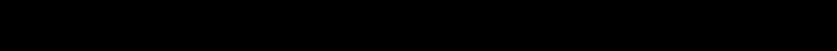

In [239]:
df_casosconfirmados.groupby("State").size()

State
aguascalientes                      3620
baja california                    12533
baja california sur                 3482
campeche                            3845
chiapas                             5547
chihuahua                           4635
coahuila                           10404
colima                              1316
distrito federal                   66444
durango                             3536
guanajuato                         16270
guerrero                            9576
hidalgo                             5898
jalisco                            11473
michoacán                           8600
morelos                             3764
méxico                             48592
nayarit                             3003
nuevo león                         13720
oaxaca                              9337
puebla                             17797
querétaro                           3155
quintana roo                        6560
san luis potosí                     6726
sinaloa   

Las variables agrupadas por Estado, y Edad nos permite conocer, como punto principal los estados con edades en años de pacientes con mínimos y máximos.

In [240]:
df_casosconfirmados.groupby("State")["Age"].agg(["min", "max"])

,min,max
State,,
aguascalientes,0,99
baja california,0,99
baja california sur,0,100
campeche,1,100
chiapas,0,106
chihuahua,0,100
coahuila,0,95
colima,0,96
distrito federal,0,105


In [241]:
df_casosconfirmados.groupby("Sex")["Age"].agg(["min", "max", "mean"])

,min,max,mean
Sex,,,
FEMENINO,0,105,44.539639
MASCULINO,0,119,45.998044


# Actividad Individual: Aplicación de la práctica en el entorno profesional


## Rafael Espinosa

# Reflexión sobre la aplicación de los conocimientos adquiridos

El área profesional en la que me desempeño es la de Tecnologías de la Información (TI), específicamente en la gestión de sistemas, análisis de información y soporte a los procesos de negocio. A lo largo de mi trayectoria profesional he participado en proyectos relacionados con la administración de plataformas tecnológicas, integración de sistemas y análisis de datos para la toma de decisiones, por lo que los conocimientos adquiridos en esta práctica tienen una aplicación directa en mi entorno laboral.

En este ámbito se generan y gestionan grandes volúmenes de información provenientes de diferentes fuentes, como sistemas transaccionales, bases de datos corporativas, aplicaciones web, plataformas financieras, sistemas de atención al cliente y herramientas de monitoreo. Estos datos incluyen registros de usuarios, transacciones, indicadores operativos, métricas de desempeño, incidencias, información financiera y reportes de gestión, los cuales deben ser almacenados y procesados de manera eficiente para generar conocimiento útil para la organización.

Las herramientas estudiadas durante esta práctica permiten abordar estas necesidades de forma integral. PostgreSQL puede utilizarse como motor de base de datos para almacenar información estructurada de manera segura y confiable. Docker facilita la implementación y administración de entornos de desarrollo y producción mediante contenedores, garantizando la portabilidad y consistencia de las aplicaciones. Por su parte, Python ofrece un amplio conjunto de librerías para la automatización de procesos, integración de datos y análisis de información, permitiendo desarrollar procesos ETL capaces de extraer datos de diferentes fuentes, transformarlos según las necesidades del negocio y cargarlos en repositorios centralizados para su posterior explotación.

La implementación de procesos ETL aportaría importantes beneficios a la organización. Entre ellos destacan la automatización de tareas repetitivas, la reducción de errores manuales, la mejora en la calidad de los datos, la integración de información proveniente de múltiples sistemas y la disponibilidad de datos consolidados para la generación de reportes e indicadores. Además, permitiría contar con información actualizada y confiable para apoyar la toma de decisiones estratégicas y operativas.

Finalmente, el análisis de los datos obtenidos permitiría identificar tendencias, evaluar el desempeño de procesos, optimizar recursos, detectar oportunidades de mejora y anticipar posibles riesgos. De esta manera, las organizaciones podrían fundamentar sus decisiones en información objetiva y oportuna, incrementando su eficiencia operativa y su capacidad para responder a los desafíos del entorno empresarial actual.


## Oscar Amagua

# Reflexión sobre la aplicación de los conocimientos adquiridos

En el laboratorio trabajamos en la creación de un proceso ETL que nos permite obtener datos, organizarlos y analizarlos para aprovecharlos de manera estratégica. Hoy en día, prácticamente cualquier empresa u organización genera datos, y saber utilizarlos representa una ventaja competitiva muy grande. En la mayoría organizaciones, la información se encuentra almacenada: en hojas de Excel, en sistemas distintos o en plataformas sin conexión entre sí. Es justamente aquí donde aplicamos lo aprendido: herramientas como PostgreSQL que
centralizan toda la información de forma organizada, Docker que nos permite generar un entorno aislado y ligero que empaqueta una aplicación junto con todo lo que necesita para funcionar y Python que automatiza tareas que antes se realizaban manualmente.

Uno de los aspectos más importantes del taller fue comprender que los datos no solo deben almacenarse, sino interpretarse. Identificar valores faltantes, calcular promedios y detectar patrones permite entender mejor la realidad de nuestro negocio, lo que se traduce en decisiones más precisas, estrategias mejor planteadas y detección temprana de problemas. Tener este detalle de análisis nos resulta valioso para cualquier área, ya que permite responder preguntas clave como: ¿qué está funcionando?, ¿qué no? y ¿qué se puede mejorar?

En el entorno laboral, trabajar con datos de esta manera hace posible la reducción del riesgo de errores humanos, ahorrar tiempo y liberar recursos para enfocarse en tareas de mayor criticidad. Una empresa puede, por ejemplo, analizar su información para impulsar ventas, optimizar procesos internos o comprender el comportamiento de sus clientes con mayor precisión.

Finalmente, esta práctica me permitió ver los datos como un activo valioso: no simples números, sino información como una fuente para la toma de decisiones. Desarrollar la capacidad de organizarlos y analizarlos fortalece el pensamiento analítico y, en un contexto empresarial, se convierte en una herramienta directa para mejorar la eficiencia, la organización y la resolución de problemas.

## Cristian Gonzalez

# Reflexión sobre la aplicación de los conocimientos adquiridos

Antes de esta práctica ya había trabajado con bases de datos y desarrollo de software, pero normalmente mi enfoque está más orientado a construir funcionalidades y resolver necesidades del negocio. Lo interesante de esta actividad fue entender mejor todo el proceso que existe detrás de los datos antes de llegar a un reporte o a un análisis. Muchas veces vemos gráficos, indicadores o estadísticas y asumimos que la información ya está lista, cuando en realidad existe un trabajo previo de integración, organización y validación de datos.

Actualmente trabajo en una empresa de telecomunicaciones como desarrollador de software. Dentro de mi trabajo se manejan datos relacionados con clientes, contratos, facturación, soporte técnico e infraestructura de red. Estos datos provienen de diferentes módulos y sistemas, por lo que no siempre se encuentran centralizados ni preparados para ser analizados de forma inmediata. Por esta razón, pude relacionar fácilmente lo realizado en la práctica con situaciones reales que se presentan en mi entorno laboral.

Durante el desarrollo de la actividad utilizamos PostgreSQL, Docker y Python para trabajar con distintas fuentes de datos. Esto me permitió comprender cómo herramientas que normalmente utilizo por separado pueden integrarse dentro de un mismo proceso para almacenar, organizar y analizar información. En un entorno empresarial, estas tecnologías pueden utilizarse para consolidar información proveniente de diferentes áreas y facilitar la generación de reportes e indicadores confiables.

Uno de los aspectos que considero más importantes es la posibilidad de automatizar tareas que normalmente se realizan de forma manual. Un proceso ETL permite recopilar información desde diferentes fuentes, transformarla según las necesidades del negocio y disponer de datos más consistentes para el análisis. Esto reduce errores, ahorra tiempo y facilita el acceso a información actualizada para la toma de decisiones.

En mi área de trabajo, el análisis de datos podría utilizarse para identificar tendencias relacionadas con contratos, incidencias de soporte, comportamiento de clientes o rendimiento de los servicios. Contar con esta información permitiría detectar problemas recurrentes, encontrar oportunidades de mejora y respaldar decisiones con datos reales en lugar de suposiciones.

Finalmente, considero que el principal aprendizaje de esta práctica fue comprender que los datos tienen valor únicamente cuando pueden transformarse en información útil. Más allá de las herramientas utilizadas, lo realmente importante es contar con procesos que permitan organizar, integrar y analizar la información para apoyar la toma de decisiones dentro de una organización.



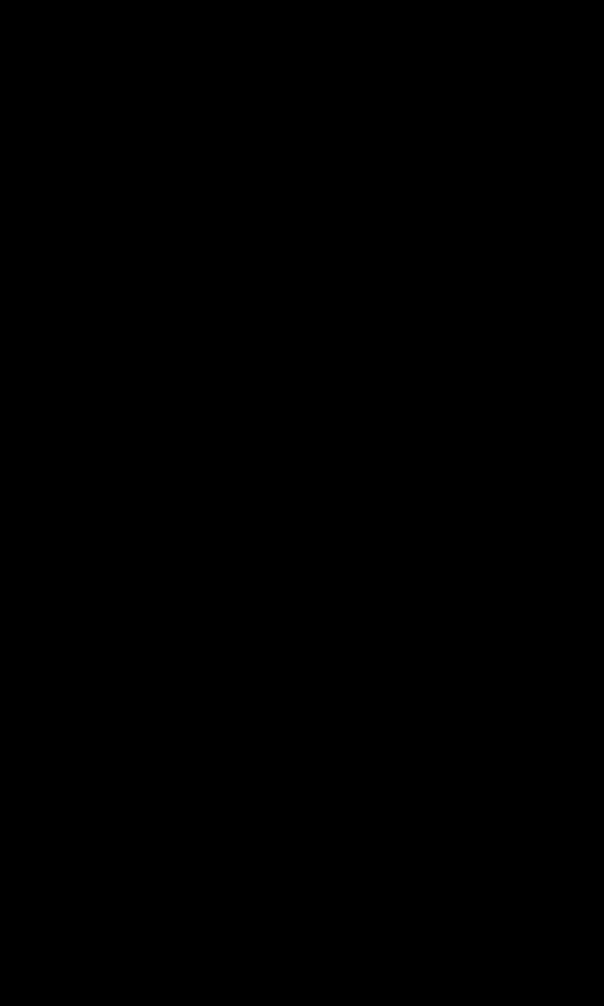

# Tarea 2: Etapa de Transformación


## Inicio del proceso de Transformación de los Datos

En esta etapa vamos a empezar a transformación la información de nuestro modelo, es aquí donde empezamos aplicar las reglas de negocio a las necesidades analíticas a las partes interesadas.

Transformación de df_resultado

In [242]:
df_parents = df_covidgeneral[['RESULTADO']].copy()

In [243]:
df_parents

,RESULTADO
0,1
1,1
2,1
3,1
4,1
...,...
879603,3
879604,3
879605,3
879606,3


In [244]:
df_covidgeneral= df_covidgeneral[df_covidgeneral['RESULTADO'].notnull()]

In [245]:
df_covidgeneral

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,2,2,1,2,2,2,2,99,1,97
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,2,2,2,2,2,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879603,879603,12,19,2,19,1,2020-07-02,2020-07-01,9999-99-99,97,...,2,2,2,2,2,2,2,1,3,97
879604,879604,3,26,2,26,2,2020-07-09,2020-07-02,9999-99-99,2,...,2,2,2,2,1,2,1,1,3,2
879605,879605,12,24,1,24,1,2020-07-16,2020-07-09,9999-99-99,97,...,2,2,2,1,2,2,2,2,3,97
879606,879606,12,9,1,9,1,2020-07-16,2020-07-11,9999-99-99,97,...,2,2,2,2,2,2,2,2,3,97


# Función Transformación de Datos

Esta función nos va a permitir transformar y limpiar los códigos de nuestras fuentes de datos, en este caso vamos a trabajar con df_covidgeneral, para asi poder mantener los códigos relaciones con nuestras fuentes de datos ==> en este caso con la estructura de el dataframe resultados.

In [246]:
cat_sector = df_sector.set_index('clave')['descripcion']
cat_entidad = df_entidades.set_index('clave_entidad')['entidad_federativa']
cat_sexo = df_sexo.set_index('clave')['descripcion']
cat_tipopaciente = df_tipopaciente.set_index('clave')['descripcion']
cat_nacionalidad = df_nacionalidad.set_index('clave')['descripcion']
cat_uci = df_respuesta.set_index('clave')['descripcion']

df_covidgeneral = df_covidgeneral.assign(
    SECTOR_DESC=lambda d: d['SECTOR'].map(cat_sector),
    ENTIDAD_UM_DESC=lambda d: d['ENTIDAD_UM'].map(cat_entidad),
    SEXO_DESC=lambda d: d['SEXO'].map(cat_sexo),
    ENTIDAD_RES_DESC=lambda d: d['ENTIDAD_RES'].map(cat_entidad),
    TIPO_PACIENTE_DESC=lambda d: d['TIPO_PACIENTE'].map(cat_tipopaciente),
    NACIONALIDAD_DESC=lambda d: d['NACIONALIDAD'].map(cat_nacionalidad),
    UCI_DESC=lambda d: d['UCI'].map(cat_uci)
)

In [247]:
df_covidgeneral

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,OTRO_CASO,RESULTADO,UCI,SECTOR_DESC,ENTIDAD_UM_DESC,SEXO_DESC,ENTIDAD_RES_DESC,TIPO_PACIENTE_DESC,NACIONALIDAD_DESC,UCI_DESC
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,99,1,97,IMSS,CIUDAD DE MÉXICO,HOMBRE,CIUDAD DE MÉXICO,AMBULATORIO,MEXICANA,NO APLICA
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,99,1,2,IMSS,CIUDAD DE MÉXICO,HOMBRE,CIUDAD DE MÉXICO,HOSPITALIZADO,MEXICANA,NO
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,99,1,2,IMSS,CHIHUAHUA,MUJER,CHIHUAHUA,HOSPITALIZADO,MEXICANA,NO
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,99,1,97,IMSS,VERACRUZ DE IGNACIO DE LA LLAVE,MUJER,VERACRUZ DE IGNACIO DE LA LLAVE,AMBULATORIO,MEXICANA,NO APLICA
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,1,1,2,ESTATAL,MÉXICO,HOMBRE,MÉXICO,HOSPITALIZADO,MEXICANA,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879603,879603,12,19,2,19,1,2020-07-02,2020-07-01,9999-99-99,97,...,1,3,97,SSA,NUEVO LEÓN,HOMBRE,NUEVO LEÓN,AMBULATORIO,MEXICANA,NO APLICA
879604,879604,3,26,2,26,2,2020-07-09,2020-07-02,9999-99-99,2,...,1,3,2,ESTATAL,SONORA,HOMBRE,SONORA,HOSPITALIZADO,MEXICANA,NO
879605,879605,12,24,1,24,1,2020-07-16,2020-07-09,9999-99-99,97,...,2,3,97,SSA,SAN LUIS POTOSÍ,MUJER,SAN LUIS POTOSÍ,AMBULATORIO,MEXICANA,NO APLICA
879606,879606,12,9,1,9,1,2020-07-16,2020-07-11,9999-99-99,97,...,2,3,97,SSA,CIUDAD DE MÉXICO,MUJER,CIUDAD DE MÉXICO,AMBULATORIO,MEXICANA,NO APLICA


### 1. Estructura general de cada fuente:

In [248]:
df_entidades.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   clave_entidad       36 non-null     int64
 1   entidad_federativa  36 non-null     str  
 2   abreviatura         36 non-null     str  
dtypes: int64(1), str(2)
memory usage: 996.0 bytes


In [249]:
df_nacionalidad.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   clave        3 non-null      int64
 1   descripcion  3 non-null      str  
dtypes: int64(1), str(1)
memory usage: 180.0 bytes


In [250]:
df_origen.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   clave        3 non-null      int64
 1   descripcion  3 non-null      str  
dtypes: int64(1), str(1)
memory usage: 180.0 bytes


In [251]:
df_resultado.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   clave        3 non-null      int64
 1   descripcion  3 non-null      str  
dtypes: int64(1), str(1)
memory usage: 180.0 bytes


In [252]:
df_sexo.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   clave        3 non-null      int64
 1   descripcion  3 non-null      str  
dtypes: int64(1), str(1)
memory usage: 180.0 bytes


In [253]:
df_respuesta.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   clave        5 non-null      int64
 1   descripcion  5 non-null      str  
dtypes: int64(1), str(1)
memory usage: 212.0 bytes


In [254]:
df_sector.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   clave        14 non-null     int64
 1   descripcion  14 non-null     str  
dtypes: int64(1), str(1)
memory usage: 356.0 bytes


In [255]:
df_tipopaciente.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   clave        3 non-null      int64
 1   descripcion  3 non-null      str  
dtypes: int64(1), str(1)
memory usage: 180.0 bytes


In [256]:
df_covidgeneral.info()

<class 'pandas.DataFrame'>
RangeIndex: 879608 entries, 0 to 879607
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   Unnamed: 0          879608 non-null  int64
 1   SECTOR              879608 non-null  int64
 2   ENTIDAD_UM          879608 non-null  int64
 3   SEXO                879608 non-null  int64
 4   ENTIDAD_RES         879608 non-null  int64
 5   TIPO_PACIENTE       879608 non-null  int64
 6   FECHA_INGRESO       879608 non-null  str  
 7   FECHA_SINTOMAS      879608 non-null  str  
 8   FECHA_DEF           879608 non-null  str  
 9   INTUBADO            879608 non-null  int64
 10  NEUMONIA            879608 non-null  int64
 11  EDAD                879608 non-null  int64
 12  NACIONALIDAD        879608 non-null  int64
 13  DIABETES            879608 non-null  int64
 14  EPOC                879608 non-null  int64
 15  ASMA                879608 non-null  int64
 16  INMUSUPR            879608 non-

In [257]:
df_covidgeneral.describe()

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,INTUBADO,NEUMONIA,EDAD,NACIONALIDAD,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
count,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,...,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000,879608.000000
mean,439803.500000,9.848755,15.687529,1.500319,15.924893,1.197416,78.244914,1.860298,42.546084,1.005068,...,2.282674,2.116812,2.373234,2.254667,2.108210,2.250986,2.207163,30.576507,1.680352,78.245828
std,253921.102128,8.248627,8.122889,0.500000,8.032383,0.398049,37.836916,0.541386,16.623810,0.071010,...,5.331251,5.189292,6.189372,5.139213,5.095619,5.083835,5.269963,44.657535,0.648907,37.835205
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,219901.750000,4.000000,9.000000,1.000000,9.000000,1.000000,97.000000,2.000000,31.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,97.000000
50%,439803.500000,12.000000,15.000000,2.000000,15.000000,1.000000,97.000000,2.000000,41.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,97.000000
75%,659705.250000,12.000000,22.000000,2.000000,23.000000,1.000000,97.000000,2.000000,53.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,99.000000,2.000000,97.000000
max,879607.000000,99.000000,32.000000,2.000000,32.000000,2.000000,99.000000,99.000000,120.000000,2.000000,...,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,99.000000,3.000000,99.000000


In [258]:
df_casosconfirmados.info()

<class 'pandas.DataFrame'>
RangeIndex: 370712 entries, 0 to 370711
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  370712 non-null  int64
 1   State       370712 non-null  str  
 2   Sex         370712 non-null  str  
 3   Age         370712 non-null  int64
 4   Date        370712 non-null  str  
 5   Confirmed   370712 non-null  int64
dtypes: int64(3), str(3)
memory usage: 17.0 MB


In [259]:
df_casosconfirmados.describe()

,Unnamed: 0,Age,Confirmed
count,370712.000000,370712.000000,370712.0
mean,269125.962321,45.319992,1.0
std,240296.062339,16.409412,0.0
min,0.000000,0.000000,1.0
25%,92677.750000,33.000000,1.0
50%,185355.500000,44.000000,1.0
75%,278033.250000,56.000000,1.0
max,724200.000000,119.000000,1.0


### 2. Número de Filas y Columnas

In [260]:
print(f"Número de Filas Tabla df_Entidades: {df_entidades.shape[0]}")
print(f"Número de Columnas Tabla df_Entidades: {df_entidades.shape[1]}")

Número de Filas Tabla df_Entidades: 36
Número de Columnas Tabla df_Entidades: 3


In [261]:
print(f"Número de Filas Tabla df_nacionalidad: {df_nacionalidad.shape[0]}")
print(f"Número de Columnas Tabla df_nacionalidad: {df_nacionalidad.shape[1]}")

Número de Filas Tabla df_nacionalidad: 3
Número de Columnas Tabla df_nacionalidad: 2


In [262]:
print(f"Número de Filas Tabla df_origen: {df_origen.shape[0]}")
print(f"Número de Columnas Tabla df_origen: {df_origen.shape[1]}")

Número de Filas Tabla df_origen: 3
Número de Columnas Tabla df_origen: 2


In [263]:
print(f"Número de Filas Tabla df_resultado: {df_resultado.shape[0]}")
print(f"Número de Columnas Tabla df_resultado: {df_resultado.shape[1]}")

Número de Filas Tabla df_resultado: 3
Número de Columnas Tabla df_resultado: 2


In [264]:
print(f"Número de Filas Tabla df_sexo: {df_sexo.shape[0]}")
print(f"Número de Columnas Tabla df_sexo: {df_sexo.shape[1]}")

Número de Filas Tabla df_sexo: 3
Número de Columnas Tabla df_sexo: 2


In [265]:
print(f"Número de Filas Tabla df_respuesta: {df_respuesta.shape[0]}")
print(f"Número de Columnas Tabla df_respuesta: {df_respuesta.shape[1]}")

Número de Filas Tabla df_respuesta: 5
Número de Columnas Tabla df_respuesta: 2


In [266]:
print(f"Número de Filas Tabla df_sector: {df_sector.shape[0]}")
print(f"Número de Columnas Tabla df_sector: {df_sector.shape[1]}")

Número de Filas Tabla df_sector: 14
Número de Columnas Tabla df_sector: 2


In [267]:
print(f"Número de Filas Tabla df_tipopaciente: {df_tipopaciente.shape[0]}")
print(f"Número de Columnas Tabla df_tipopaciente: {df_tipopaciente.shape[1]}")

Número de Filas Tabla df_tipopaciente: 3
Número de Columnas Tabla df_tipopaciente: 2


In [268]:
print(f"Número de Filas Tabla df_covidgeneral: {df_covidgeneral.shape[0]}")
print(f"Número de Columnas Tabla df_covidgeneral: {df_covidgeneral.shape[1]}")

Número de Filas Tabla df_covidgeneral: 879608
Número de Columnas Tabla df_covidgeneral: 33


In [269]:
print(f"Número de Filas Tabla df_casosconfirmados: {df_casosconfirmados.shape[0]}")
print(f"Número de Columnas Tabla df_casosconfirmados: {df_casosconfirmados.shape[1]}")

Número de Filas Tabla df_casosconfirmados: 370712
Número de Columnas Tabla df_casosconfirmados: 6


### 3. Tipo de Datos

In [270]:
print (df_entidades.dtypes)

clave_entidad         int64
entidad_federativa      str
abreviatura             str
dtype: object


In [271]:
print (df_nacionalidad.dtypes)

clave          int64
descripcion      str
dtype: object


In [272]:
print (df_origen.dtypes)

clave          int64
descripcion      str
dtype: object


In [273]:
print (df_resultado.dtypes)

clave          int64
descripcion      str
dtype: object


In [274]:
print (df_sexo.dtypes)

clave          int64
descripcion      str
dtype: object


In [275]:
print (df_respuesta.dtypes)

clave          int64
descripcion      str
dtype: object


In [276]:
print (df_respuesta.dtypes)

clave          int64
descripcion      str
dtype: object


In [277]:
print (df_sector.dtypes)

clave          int64
descripcion      str
dtype: object


In [278]:
print (df_tipopaciente.dtypes)

clave          int64
descripcion      str
dtype: object


In [279]:
print (df_covidgeneral.dtypes)

Unnamed: 0            int64
SECTOR                int64
ENTIDAD_UM            int64
SEXO                  int64
ENTIDAD_RES           int64
TIPO_PACIENTE         int64
FECHA_INGRESO           str
FECHA_SINTOMAS          str
FECHA_DEF               str
INTUBADO              int64
NEUMONIA              int64
EDAD                  int64
NACIONALIDAD          int64
DIABETES              int64
EPOC                  int64
ASMA                  int64
INMUSUPR              int64
HIPERTENSION          int64
OTRA_CON              int64
CARDIOVASCULAR        int64
OBESIDAD              int64
RENAL_CRONICA         int64
TABAQUISMO            int64
OTRO_CASO             int64
RESULTADO             int64
UCI                   int64
SECTOR_DESC             str
ENTIDAD_UM_DESC         str
SEXO_DESC               str
ENTIDAD_RES_DESC        str
TIPO_PACIENTE_DESC      str
NACIONALIDAD_DESC       str
UCI_DESC                str
dtype: object


In [280]:
print (df_casosconfirmados.dtypes)

Unnamed: 0    int64
State           str
Sex             str
Age           int64
Date            str
Confirmed     int64
dtype: object


### 4. Columnas relevantes para el proyecto.

### 5. Valores nulos o inconsistentes.

In [281]:
df_entidades = df_entidades[df_entidades['clave_entidad'].notnull()]
df_entidades

,clave_entidad,entidad_federativa,abreviatura
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG
